# Marketing Mix Modeling (MMM) — Baseline Model

## Objective
Estimate the impact of marketing channels (TV, Radio, Social, Search) on sales using a baseline regression model.

## Note
This is a baseline MMM without adstock or saturation.
    

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [5]:
path = r"C:\Users\user\MMM"

In [9]:
df = pd.read_csv(path + "/marketing_mix_mmm_dataset.csv")
df.head()

,date,sales,tv_spend,radio_spend,social_spend,search_spend
0,2021-01-04,2094.504164,209.934283,168.561214,112.279407,142.928450
1,2021-01-11,2233.502217,202.056181,149.243894,111.416937,144.451476
2,2021-01-18,2313.871273,222.526397,125.505854,115.399546,149.961833
3,2021-01-25,2411.867514,244.644793,154.121850,101.437700,127.347161
4,2021-02-01,2439.878360,213.905859,130.197497,106.766370,138.277385


## Data Preparation

In [10]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          156 non-null    datetime64[us]
 1   sales         156 non-null    float64       
 2   tv_spend      156 non-null    float64       
 3   radio_spend   156 non-null    float64       
 4   social_spend  156 non-null    float64       
 5   search_spend  156 non-null    float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 7.4 KB


## Sales Trend

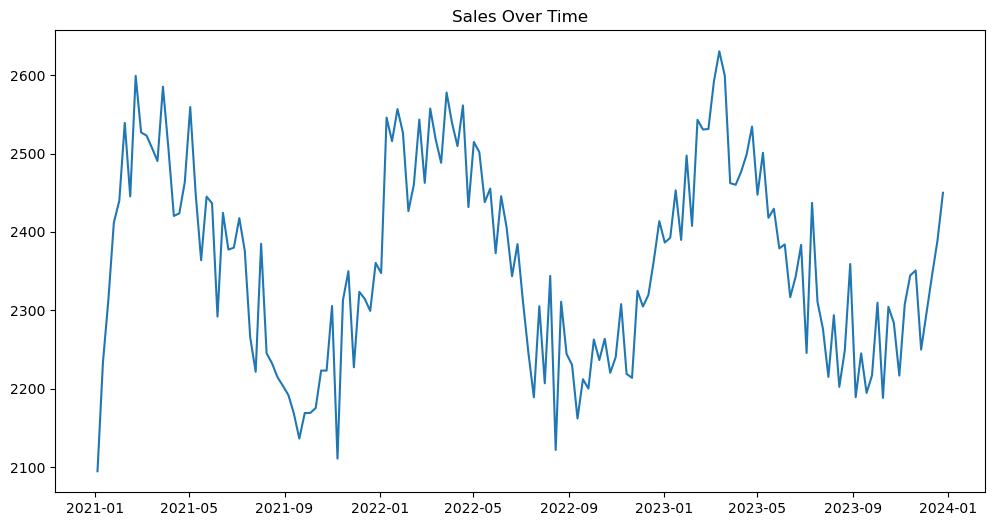

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['sales'])
plt.title("Sales Over Time")
plt.show()

## Channel Trends

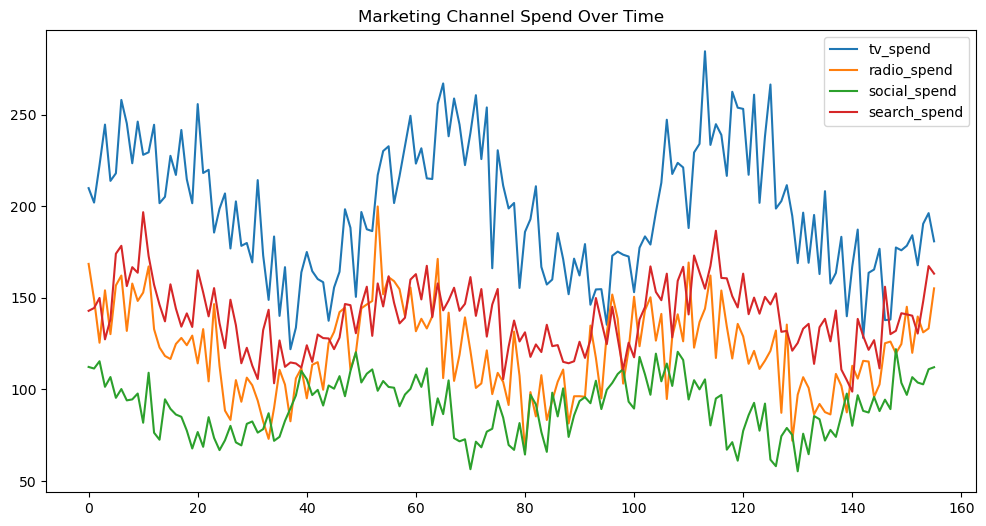

In [12]:
df[['tv_spend', 'radio_spend', 'social_spend', 'search_spend']].plot(figsize=(12,6))
plt.title("Marketing Channel Spend Over Time")
plt.show()

## Correlation Analysis

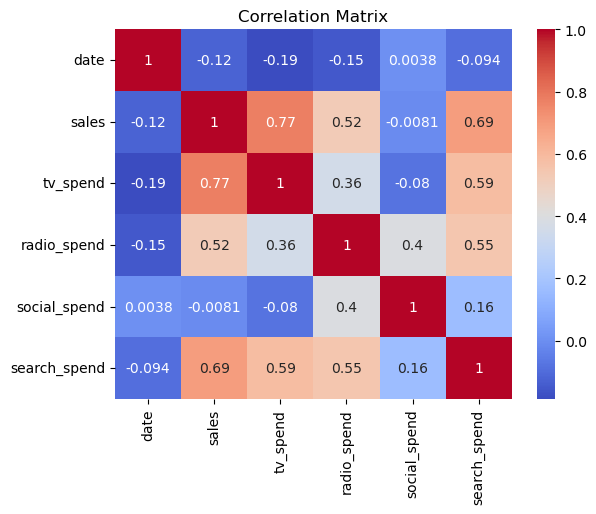

In [13]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Baseline MMM Model

In [15]:
X = df[['tv_spend', 'radio_spend', 'social_spend', 'search_spend']]
y = df['sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     93.63
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           7.03e-40
Time:                        14:39:18   Log-Likelihood:                -878.01
No. Observations:                 156   AIC:                             1766.
Df Residuals:                     151   BIC:                             1781.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1656.3984     51.950     31.884   

## Predictions

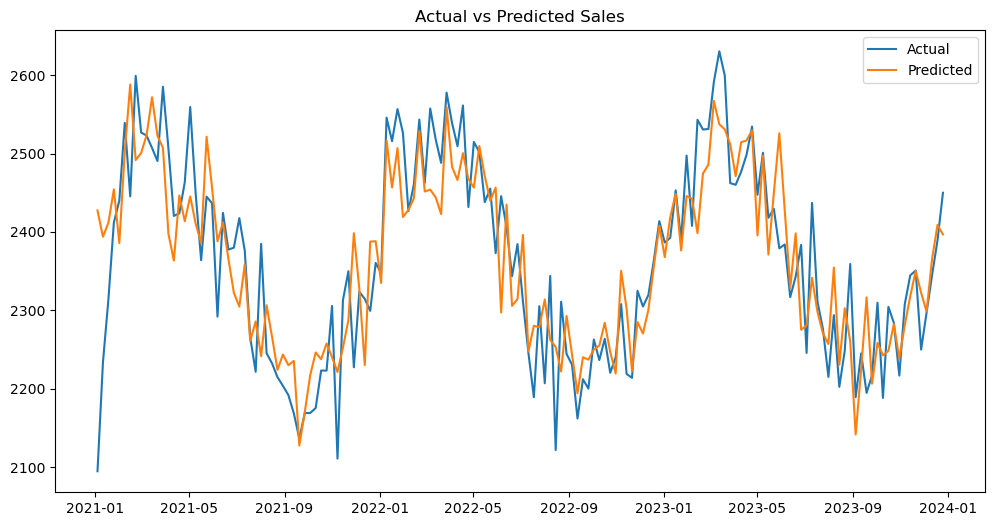

In [16]:
df['predicted_sales'] = model.predict(X)

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['sales'], label='Actual')
plt.plot(df['date'], df['predicted_sales'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

## Adstock

In [17]:
 def adstock(x, alpha=0.5):
    result = [x[0]]
    for i in range(1, len(x)):
        result.append(x[i] + alpha * result[i-1])
    return result

In [18]:
df['tv_adstock'] = adstock(df['tv_spend'], 0.6)
df['radio_adstock'] = adstock(df['radio_spend'], 0.5)
df['social_adstock'] = adstock(df['social_spend'], 0.4)
df['search_adstock'] = adstock(df['search_spend'], 0.5)

In [19]:
X = df[['tv_adstock', 'radio_adstock', 'social_adstock', 'search_adstock']]
X = sm.add_constant(X)

model_adstock = sm.OLS(y, X).fit()

print(model_adstock.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     178.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.22e-56
Time:                        14:44:42   Log-Likelihood:                -838.99
No. Observations:                 156   AIC:                             1688.
Df Residuals:                     151   BIC:                             1703.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           1508.4223     47.786     31.

## Diminishing Returns (Saturation)

In [20]:
def saturation(x, k=200):
    return x / (1 + x / k)


In [21]:
df['tv_sat'] = saturation(df['tv_adstock'], 300)
df['radio_sat'] = saturation(df['radio_adstock'], 200)
df['social_sat'] = saturation(df['social_adstock'], 150)
df['search_sat'] = saturation(df['search_adstock'], 220)

In [22]:
X = df[['tv_sat', 'radio_sat', 'social_sat', 'search_sat']]
X = sm.add_constant(X)

model_sat = sm.OLS(y, X).fit()

print(model_sat.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     151.7
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           7.75e-52
Time:                        14:47:34   Log-Likelihood:                -849.44
No. Observations:                 156   AIC:                             1709.
Df Residuals:                     151   BIC:                             1724.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.5616    106.609      4.620      0.0

# ROI Calculation + Budget Optimization

## Calculate contribution

In [28]:
contribution = pd.DataFrame({
    'tv': df['tv_sat'] * model_sat.params['tv_sat'],
    'radio': df['radio_sat'] * model_sat.params['radio_sat'],
    'social': df['social_sat'] * model_sat.params['social_sat'],
    'search': df['search_sat'] * model_sat.params['search_sat']
})

## Total contribution per channel

In [29]:
channel_contribution = contribution.sum()
print(channel_contribution)

tv        170030.694641
radio     112492.410726
social     -4854.463354
search     14021.434860
dtype: float64


In [31]:
total_spend = pd.Series({
    'tv': df['tv_spend'].sum(),
    'radio': df['radio_spend'].sum(),
    'social': df['social_spend'].sum(),
    'search': df['search_spend'].sum()
})

## ROI

In [32]:
roi = channel_contribution / total_spend
print(roi)

tv        5.494152
radio     5.947573
social   -0.344529
search    0.643639
dtype: float64
